Goal: go from the HMF to the UVLF by parameterizing each step in the process \
Following Shen+23

In [1]:
import numpy as np
import zeus21
from classy import Class
import cosmo_calc
import importlib
from astropy import constants as c
from astropy import units as u
import eplots
from scipy.interpolate import interp1d
import hmf as halomassfunction

#b84557
#03abc1
#d4d000
#294450
#bf5700
#719920
#8aa0ff


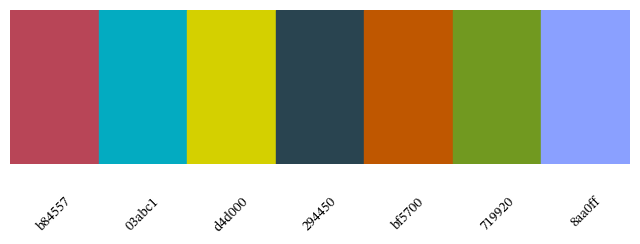

In [2]:
eplots.plot_colors()

In [287]:
z = 9

# HMF

In [288]:
# Trying Tinker HMF
# M_halo = np.logspace(9, 14, 100)
#params, HMFintclass = cosmo_calc.hmf_zeus(z = z, HMF_CHOICE='ST')
# hmf = HMFintclass.HMF_int(M_halo, z)
params = cosmo_calc.get_params()
my_hmf = halomassfunction.hmf.MassFunction(Mmin = 9, Mmax = 14, dlog10m = .05, hmf_model = 'Tinker10', z = z)
M_halo = my_hmf.m/params['h']
hmf = my_hmf.dndm*params['h']**4

Text(0.5, 1.0, 'HMF, $z=9$')

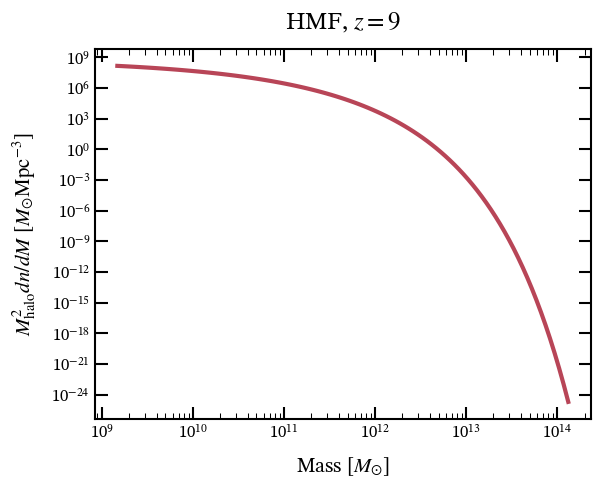

In [289]:
fig, ax = plt.subplots()
ax.loglog(M_halo, hmf*M_halo**2)
ax.set_ylabel(r'$M_{\rm{halo}}^2 dn/dM$ [$M_{\odot}\rm{Mpc}^{-3}$]')
ax.set_xlabel(r'Mass [$M_{\odot}$]')
ax.set_title(f'HMF, $z={z}$')

# Mass accretion

In [290]:
def calc_M_dot(M_h, params, z = 0):
    return 25.3*(M_h/1e12)**(1.1)*(1+(1.65*z))*np.sqrt((params['Omega_m']*(1+z)**3)+params['Omega_L'])

In [291]:
m_dots = calc_M_dot(M_halo, params, z)

Text(0.5, 1.0, 'Mass accretion rate')

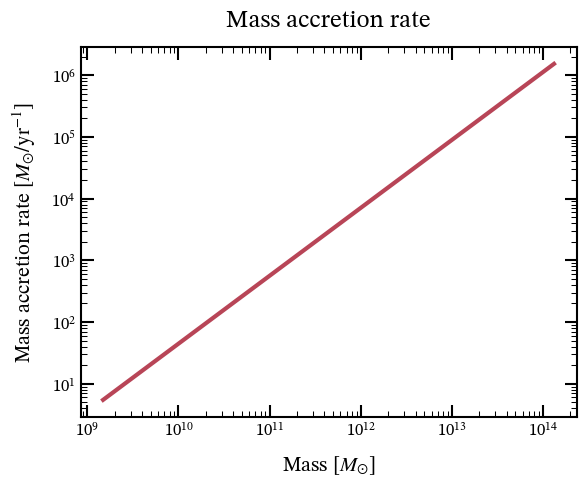

In [292]:
fig, ax = plt.subplots()
ax.loglog(M_halo, m_dots)
ax.set_xlabel(r'Mass [$M_{\odot}$]')
ax.set_ylabel(r'Mass accretion rate [$M_{\odot}/\rm{yr}^{-1}$]')
ax.set_title('Mass accretion rate')

In [308]:
def calc_SFE(M_h, eps_0 = 0.1, M_0 = 1e12, alpha = 0.6, beta = 0.5):
    return 2*eps_0/((M_h/M_0)**-alpha+(M_h/M_0)**beta)

In [309]:
SFE = calc_SFE(M_halo)

Text(0.5, 1.0, 'SFE')

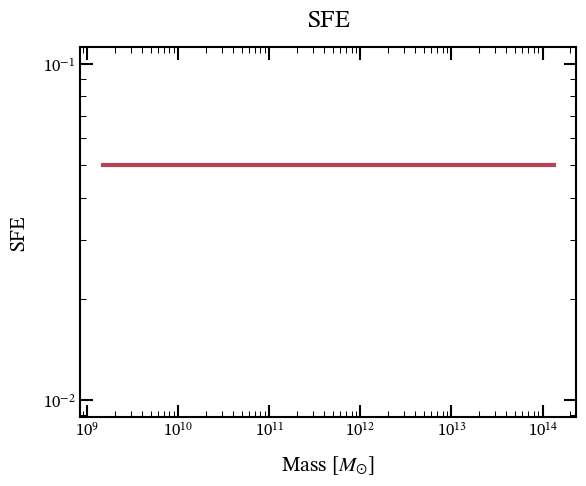

In [310]:
fig, ax = plt.subplots()
ax.loglog(M_halo, SFE)
ax.set_xlabel(r'Mass [$M_{\odot}$]')
ax.set_ylabel(r'SFE')
ax.set_title('SFE')

In [311]:
def calc_SFR(M_h, params, z=0):
    fb = params['Omega_b']/params['Omega_m']
    M_dot = calc_M_dot(M_h, params, z)
    eps_star = calc_SFE(M_h)
    return fb*M_dot*eps_star

In [312]:
sfrs = calc_SFR(M_halo, params, z)

Text(0.5, 1.0, 'SFR')

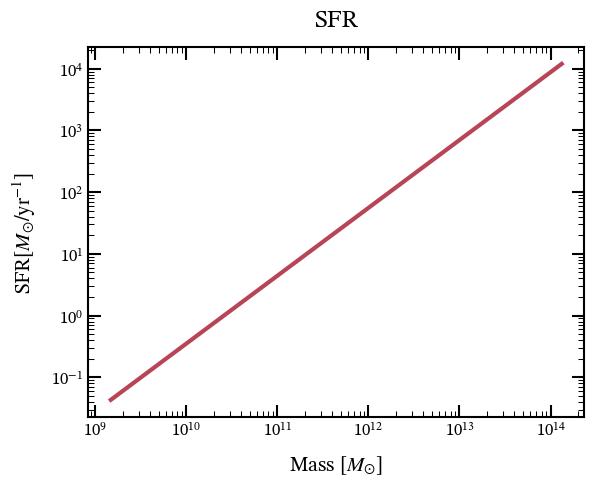

In [313]:
fig, ax = plt.subplots()
ax.loglog(M_halo, sfrs)
ax.set_xlabel(r'Mass [$M_{\odot}$]')
ax.set_ylabel(r'SFR[$M_{\odot}/\rm{yr}^{-1}$]')
ax.set_title('SFR')

In [314]:
def calc_L_UV(M_h, params, z=0, Kappa_UV = 1.15e-28):
    SFR = calc_SFR(M_h, params, z)
    return SFR/Kappa_UV

def calc_M_UV(M_h, params, z=0):
    L_UV = calc_L_UV(M_h, params, z)
    M_UV = 51.63-(2.5*np.log10(L_UV)) # Same as Zeus
    return M_UV

def M_to_L(M_UV):
    return 10**(0.4*(51.63-M_UV))

In [315]:
L_UV = calc_L_UV(M_halo, params, z)
M_UV = calc_M_UV(M_halo, params, z)

In [316]:
# Shen data for comparison
# curve_MUV = np.array([-16.01484019211786, -2.815453815043948,
# -17.350229363505903, -3.1980023281602312,
# -19.021853821204303, -3.871054662015942,
# -19.997693922074475, -4.39653801466181,
# -21.00686431468839, -5.137571346589897,
# -21.768960854741977, -5.950698690481298,
# -22.418814443679437, -6.83218206586089,
# -22.96754485653375, -7.843992421281851
# ]).reshape(-1, 2)

shen_curve = np.array([-15.997965648522188, -2.699480617612502,
-16.492167746810427, -2.9178288072472736,
-16.885291638815424, -3.0945765850296647,
-17.222296492196808, -3.260878590734152,
-17.57051934087012, -3.427197203389479,
-17.91882937603534, -3.6246040280159266,
-18.25583422941672, -3.790906033720414,
-18.750181638524804, -4.061067909973719,
-19.120985788601818, -4.279233423149259,
-19.401929727687524, -4.4558151314232575,
-19.795257054840302, -4.705102070471597,
-20.222354616524747, -4.99588977966728,
-20.750675695312275, -5.3800915873338795,
-21.132930337992967, -5.681175606049913,
-21.459007817722107, -5.951088378040629,
-21.86387282397047, -6.314382034600582,
-22.246418088290856, -6.719093426553684,
-22.583975122787642, -7.082287441408602,
-22.83167194629312, -7.403897651361978,
-23.056874654886805, -7.704749172766261,
-23.248394315440727, -7.99518813599432]).reshape(-1,2)
shen_phi_UV = shen_curve[:,1] # This is already in log space, so I won't have to take the log later
shen_M_UV = shen_curve[:,0]

In [317]:
def interpolate(x0, y0, x1):
    # Make sure the range you're interpolating is defined for both
    defined_range = np.where((x1 >= np.min(x0)) & (x1 <= np.max(x0)))[0] # This is the indices in x1 where x0 is defined. Use it to cut
    # x1 and y1 when you're plotting to make sure everything is consistent
    try: 
        interpolater = interp1d(x0, y0)
        return interpolater(x1[defined_range]), defined_range
    except: # If your x0 is strictly DECREASING, this will work by switching the order of everything
        interpolater  = interp1d(x0[::-1], y0[::-1])
        return interpolator(x1[defined_range])[::-1], defined_range

In [318]:
my_uvlf = np.log10(hmf*np.abs(np.gradient(M_halo, M_UV))) # Must take the absolute value of dM/dM_UV
my_uvlf_compare, def_range = interpolate(M_UV, my_uvlf, shen_M_UV)

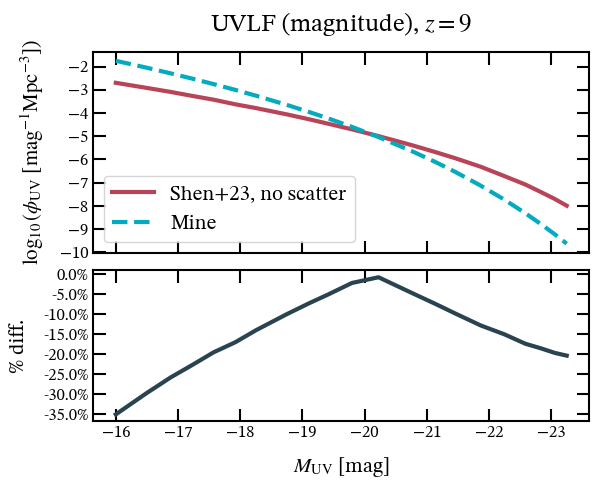

In [319]:
fig, axs = eplots.percent_diff_plot(shen_M_UV, shen_phi_UV, my_uvlf_compare, labels = ['Shen+23, no scatter', 'Mine'])

axs[0].invert_xaxis()
axs[1].set_xlabel(r'$M_{\rm{UV}}$ [mag]')
axs[0].set_ylabel(r'$\log_{10}(\phi_{\rm{UV}}$ [$\rm{mag}^{-1} \rm{Mpc}^{-3}$])')
axs[1].set_ylabel('% diff.')
axs[0].set_title(f'UVLF (magnitude), $z={z}$')
axs[0].legend()

#fig.savefig('/Users/eb35267/Desktop/figures/ongoing/UVLF_mag.png')

#### def calc_M_UV_dust(M_halo, params, z=0):
    """
    This makes galaxies fainter than ~18.5 brighter...
    """
    M_UV = calc_M_UV(M_halo, params, z)
    M_UV_obs = (M_UV - 6.35)/1.34
    M_UV_obs = np.where(M_UV_obs > M_UV, M_UV_obs, M_UV)

    return M_UV_obs

In [243]:
shen_with_dust = np.array([-15.990384615384615, -2.699481865284974,
-16.641025641025642, -2.9689119170984455,
-17.459935897435898, -3.373056994818653,
-18.536858974358974, -3.9119170984455955,
-19.17628205128205, -4.3160621761658025,
-19.849358974358974, -4.875647668393782,
-20.567307692307693, -5.601036269430051,
-21.060897435897438, -6.181347150259067,
-21.621794871794872, -7,
-22.16025641025641, -7.974093264248704]).reshape(-1, 2)
shen_phi_dust = shen_with_dust[:,1] # This is already in log space, so I won't have to take the log later
shen_M_UV_dust = shen_with_dust[:,0]

In [244]:
M_UV_dust = calc_M_UV_dust(M_halo, params, z)
my_uvlf_dust = np.log10(hmf*np.abs(np.gradient(M_halo, M_UV_dust))) # Must take the absolute value of dM/dM_UV
# my_uvlf_compare_dust = interpolate(M_UV_dust, my_uvlf_dust, shen_M_UV_dust)
shen_comp, def_range = interpolate(shen_M_UV_dust, shen_phi_dust, M_UV_dust)

Text(0.5, 1.0, 'UVLF, $z=9$')

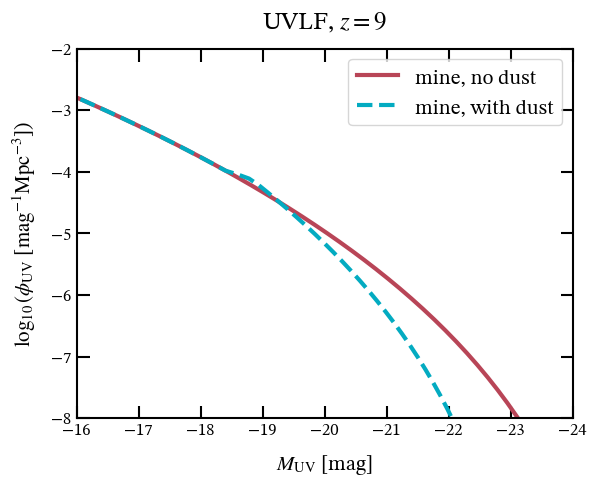

In [245]:
fig, ax = plt.subplots()
ax.plot(M_UV, my_uvlf, label = 'mine, no dust')
ax.plot(M_UV_dust, my_uvlf_dust, label = 'mine, with dust', linestyle = '--')
ax.invert_xaxis()
ax.legend()
ax.set_ylim(-8, -2)
ax.set_xlim(-16, -24)

ax.set_xlabel(r'$M_{\rm{UV}}$ [mag]')
ax.set_ylabel(r'$\log_{10}(\phi_{\rm{UV}}$ [$\rm{mag}^{-1} \rm{Mpc}^{-3}$])')
ax.set_title(f'UVLF, $z={z}$')

#fig.savefig('/Users/eb35267/Desktop/figures/ongoing/problems/UVLF_dust.png')

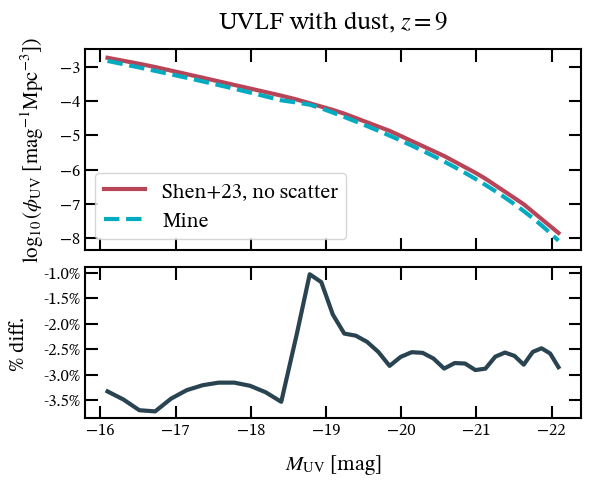

In [247]:
fig, axs = eplots.percent_diff_plot(M_UV_dust[def_range], shen_comp, my_uvlf_dust[def_range], labels = ['Shen+23, no scatter', 'Mine'])
axs[0].invert_xaxis()
axs[1].set_xlabel(r'$M_{\rm{UV}}$ [mag]')
axs[0].set_ylabel(r'$\log_{10}(\phi_{\rm{UV}}$ [$\rm{mag}^{-1} \rm{Mpc}^{-3}$])')
axs[1].set_ylabel('% diff.')
axs[0].set_title(f'UVLF with dust, $z={z}$')
axs[0].legend()

#fig.savefig('/Users/eb35267/Desktop/figures/ongoing/problems/UVLF_dust_comparison.png')